# Brain age comparison
This model constructs two brain age models
- Linear ridge regression
- Non-linear random forest regression (xgboost)

The model outputs are normalized using a kernal method to remove the age bias. The brain age gap (BAG) is then calculated as the difference between the predicted brain age and the chronological age.

The BAG is then related to estimated Tau levels in the brain from PET imaging and also to birth weight. We also compare to total brain volume and hippocampal volume to see if the BAG provides any additional information beyond these traditional measures of brain health. Comaprison with longitudinal data is also performed.

In [1]:
from pathlib import Path
import glob
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.linear_model import ElasticNet

import seaborn as sns
import statsmodels.formula.api as smf

import json
import pickle

import xgboost as xgb
from itertools import product


In [2]:
# Colors 
colors = {'Orange': '#e69f00', 'Sky Blue': '#56b4e9', 'Bluish Green': '#009e73', 'Yellow': '#f0e442', 'Blue': '#0072b2', 'Vermillion': '#d55e00', 'Reddish Purple': '#cc79a7'}
# Set defalt color wheel
sns.set_palette(sns.color_palette(colors.values()))
mpl.rcParams['figure.dpi'] = 300
# Remove spines
sns.set_style({'axes.spines.right': False, 'axes.spines.top': False})

## Loading the data

In [ ]:
dataset_path = 'datapath.csv'
df = pd.read_csv(dataset_path)

df.head()

feature_set_file = 'feature_sets_various_sizes.json'
with open(feature_set_file, 'r') as f:
    features = json.load(f)
    
# Use the feature set with the most features for the main analysis
features = features[str(max(map(int, features.keys())))][0]


/tmp/ipykernel_44873/3955230166.py:2: DtypeWarning: Columns (268) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(dataset_path)


In [4]:
# Get the datasets that have either bw or esttau values
datasets_with_bw_or_esttau = df[df['bw'].notna() | df['esttau'].notna()]['dataset'].unique()
print("Datasets with bw or esttau values:", datasets_with_bw_or_esttau)
# Keep only those datasets
df = df[df['dataset'].isin(datasets_with_bw_or_esttau)]

Datasets with bw or esttau values: ['adni' 'dlbs' 'habs' 'preventad' 'uio' 'ukb' 'ukb_sc']


In [5]:
# Number of samples in each dataset
print(df['dataset'].value_counts())

dataset
ukb_sc       42590
adni          5909
ukb           2551
preventad     1367
uio            744
dlbs           692
habs           690
Name: count, dtype: int64


In [6]:
# Create a dataset with a single session per subject
df_subject_only = df.drop_duplicates(subset=['rid'])
# Get the number of subjects in each dataset with valid bw or esttau values
print("bw")
print(df_subject_only[df_subject_only['bw'].notna()]['dataset'].value_counts())
print(f"Total bw: {df_subject_only[df_subject_only['bw'].notna()]['dataset'].value_counts().sum()}")
print("education")
print(df_subject_only[df_subject_only['edu.scale'].notna()]['dataset'].value_counts())
print(f"Total education: {df_subject_only[df_subject_only['edu.scale'].notna()]['dataset'].value_counts().sum()}")
print("esttau")
print(df_subject_only[df_subject_only['esttau'].notna()]['dataset'].value_counts())
print(f"Total esttau: {df_subject_only[df_subject_only['esttau'].notna()]['dataset'].value_counts().sum()}")
print("TotalGrayVol")
print(df_subject_only[df_subject_only['TotalGrayVol'].notna()]['dataset'].value_counts())
print(f"Total TotalGrayVol: {df_subject_only[df_subject_only['TotalGrayVol'].notna()]['dataset'].value_counts().sum()}")

bw
dataset
ukb_sc    25686
ukb         849
uio         160
Name: count, dtype: int64
Total bw: 26695
education
dataset
ukb_sc       41010
adni          2093
ukb           1288
dlbs           351
preventad      306
habs           284
uio            225
Name: count, dtype: int64
Total education: 45557
esttau
dataset
adni         762
habs         195
dlbs         131
preventad    111
Name: count, dtype: int64
Total esttau: 1199
TotalGrayVol
dataset
ukb_sc       41031
adni          2094
ukb           1288
dlbs           352
preventad      306
uio            297
habs           284
Name: count, dtype: int64
Total TotalGrayVol: 45652


In [7]:
df['dataset'].unique()

array(['adni', 'dlbs', 'habs', 'preventad', 'uio', 'ukb', 'ukb_sc'],
      dtype=object)

In [ ]:
train_dataset = 'ukb_sc' # Train the data on cross-sectional UK Biobank (UKB) and test on the other datasets.
fit_models = False

In [9]:
# For all features clip the top and bottom 0.1% of the values to remove outliers
for feature in features:
    lower_bound = df[feature].quantile(0.001)
    upper_bound = df[feature].quantile(0.999)
    df[feature] = df[feature].clip(lower=lower_bound, upper=upper_bound)

In [10]:
# Getting the number of features
print(f"Number of features: {len(features)}")

Number of features: 121


## Elastic Net model

In [11]:
def get_train_val_test_split(df, train_dataset, train_folds, val_folds):
    train_df = df[(df["dataset"] == train_dataset) & (df["test_fold"].isin(train_folds + val_folds))]
    val_df = train_df[train_df['test_fold'].isin(val_folds)]
    train_df = train_df[train_df['test_fold'].isin(train_folds)]

    # The rest goes in the test set
    test_df = df[~(df.index.isin(train_df.index) | df.index.isin(val_df.index))]

    # Remove rows with missing values in the selected features
    train_df = train_df.dropna(subset=features + ["age"])
    val_df = val_df.dropna(subset=features + ["age"])
    test_df = test_df.dropna(subset=features + ["age"])

    train_idxs = train_df.index.values
    val_idxs = val_df.index.values
    test_idxs = test_df.index.values

    print(f"Number of training samples: {len(train_idxs)}, Number of validation samples: {len(val_idxs)}, Number of test samples: {len(test_idxs)}")
    ages_train = df.loc[train_idxs, "age"].values
    ages_val = df.loc[val_idxs, "age"].values
    ages_test = df.loc[test_idxs, "age"].values

    ages_train_norm = df.loc[train_idxs, "age"].values/100
    ages_val_norm = df.loc[val_idxs, "age"].values/100
    ages_test_norm = df.loc[test_idxs, "age"].values/100

    features_train = df.loc[train_idxs, features].values
    features_val = df.loc[val_idxs, features].values
    features_test = df.loc[test_idxs, features].values
    
    return train_idxs, val_idxs, test_idxs, ages_train, ages_val, ages_test, ages_train_norm, ages_val_norm, ages_test_norm, features_train, features_val, features_test



In [12]:
train_folds = [1, 2, 3]
val_folds = [4]
test_folds = [5]

train_idxs, val_idxs, test_idxs, ages_train, ages_val, ages_test, ages_train_norm, ages_val_norm, ages_test_norm, features_train, features_val, features_test = get_train_val_test_split(df, train_dataset, train_folds, val_folds)


if fit_models:
    alphas = np.logspace(-8, -3, 10)
    l1_ratios = np.linspace(0, 1, 20)

    best_alpha = None
    best_l1_ratio = None
    best_score = float("inf")
    scores = np.zeros((len(alphas), len(l1_ratios)))
    for alpha_idx, alpha in enumerate(alphas):
        print(f"{alpha_idx+1}/{len(alphas)}: Testing alpha={alpha}")
        for l1_idx, l1_ratio in enumerate(l1_ratios):

            model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=1000, tol=1e-4)
            model.fit(features_train, ages_train_norm)
            preds = model.predict(features_val)
            mae = np.mean(np.abs(preds - ages_val_norm))
            scores[alpha_idx, l1_idx] = mae


    best_alpha_idx, best_l1_idx = np.unravel_index(np.argmin(scores), scores.shape)
    best_alpha = alphas[best_alpha_idx]
    best_l1_ratio = l1_ratios[best_l1_idx]
    print(f"Best alpha: {best_alpha}, Best l1_ratio: {best_l1_ratio}, Best MAE: {scores[best_alpha_idx, best_l1_idx]}")

    # Save the hyperparameter grid
    with open("/fp/projects01/ec201/userdata/ec-edvardsg/anti_brain_age_data/elastic_net_hyperparameters_scores.pkl", "wb") as f:
        pickle.dump({
            "alphas": alphas,
            "l1_ratios": l1_ratios,
            "scores": scores
        }, f)
        
else:
    # Load the hyperparameter grid
    with open("/fp/projects01/ec201/userdata/ec-edvardsg/anti_brain_age_data/elastic_net_hyperparameters_scores.pkl", "rb") as f:
        hyperparams = pickle.load(f)
        alphas = hyperparams["alphas"]
        l1_ratios = hyperparams["l1_ratios"]
        scores = hyperparams["scores"]
        
best_alpha_idx, best_l1_idx = np.unravel_index(np.argmin(scores), scores.shape)
best_alpha = alphas[best_alpha_idx]
best_l1_ratio = l1_ratios[best_l1_idx]
print(f"Best alpha: {best_alpha}, Best l1_ratio: {best_l1_idx}, Best MAE: {scores[best_alpha_idx, best_l1_idx]}")



Number of training samples: 25592, Number of validation samples: 8598, Number of test samples: 20353
Best alpha: 1e-08, Best l1_ratio: 0, Best MAE: 0.039813619100211826


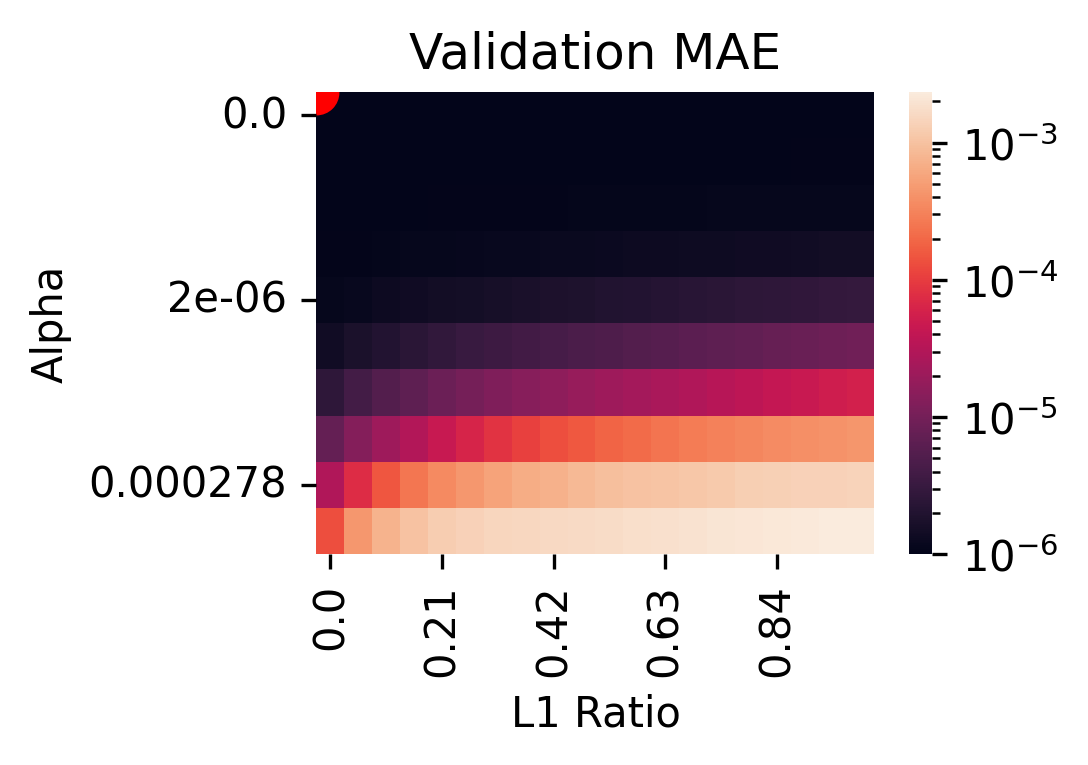

In [13]:
# Plot the scores as a function of alpha using kernal density estimation
fig, ax = plt.subplots(figsize=(3, 2), dpi=300)
# Use a log norm
scores_normed = scores - scores.min() + 1e-6
norm = mpl.colors.LogNorm(vmin=np.min(scores_normed), vmax=np.max(scores_normed))
sns.heatmap(scores_normed, xticklabels=np.round(l1_ratios, 2), yticklabels=np.round(alphas, 6), ax=ax, norm=norm)
ax.set_xlabel("L1 Ratio")
ax.set_ylabel("Alpha")
ax.set_title("Validation MAE")

# Higlight the best alpha and l1_ratio
ax.scatter(best_l1_idx, best_alpha_idx, color="red", s=100)
ax.text(best_l1_idx, best_alpha_idx, "Best", color="white", fontsize=12, ha="right", va="bottom")

# Skip every other tick to avoid overcrowding
tick_interval = 4
ax.set_yticks(ax.get_yticks()[::tick_interval])
ax.set_xticks(ax.get_xticks()[::tick_interval])
plt.show()

/tmp/ipykernel_44873/3902765590.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["elastic_net_gap"] = np.nan


Train folds: [0, 1, 2], Val fold: 4, Test fold: 3


Number of training samples: 25360, Number of validation samples: 8598, Number of test samples: 20585


/fp/homes01/u01/ec-edvardsg/.conda/envs/jax_numpyro_env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.138e+01, tolerance: 1.420e-03
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


Train folds: [1, 2, 3], Val fold: 0, Test fold: 4
Number of training samples: 25592, Number of validation samples: 8400, Number of test samples: 20551


/fp/homes01/u01/ec-edvardsg/.conda/envs/jax_numpyro_env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.150e+01, tolerance: 1.424e-03
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


Train folds: [0, 1, 4], Val fold: 3, Test fold: 2
Number of training samples: 25625, Number of validation samples: 8632, Number of test samples: 20286


/fp/homes01/u01/ec-edvardsg/.conda/envs/jax_numpyro_env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.140e+01, tolerance: 1.434e-03
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


Train folds: [0, 3, 4], Val fold: 2, Test fold: 1
Number of training samples: 25630, Number of validation samples: 8333, Number of test samples: 20580


/fp/homes01/u01/ec-edvardsg/.conda/envs/jax_numpyro_env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.081e+01, tolerance: 1.422e-03
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


Train folds: [2, 3, 4], Val fold: 1, Test fold: 0
Number of training samples: 25563, Number of validation samples: 8627, Number of test samples: 20353


/fp/homes01/u01/ec-edvardsg/.conda/envs/jax_numpyro_env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.113e+01, tolerance: 1.408e-03
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


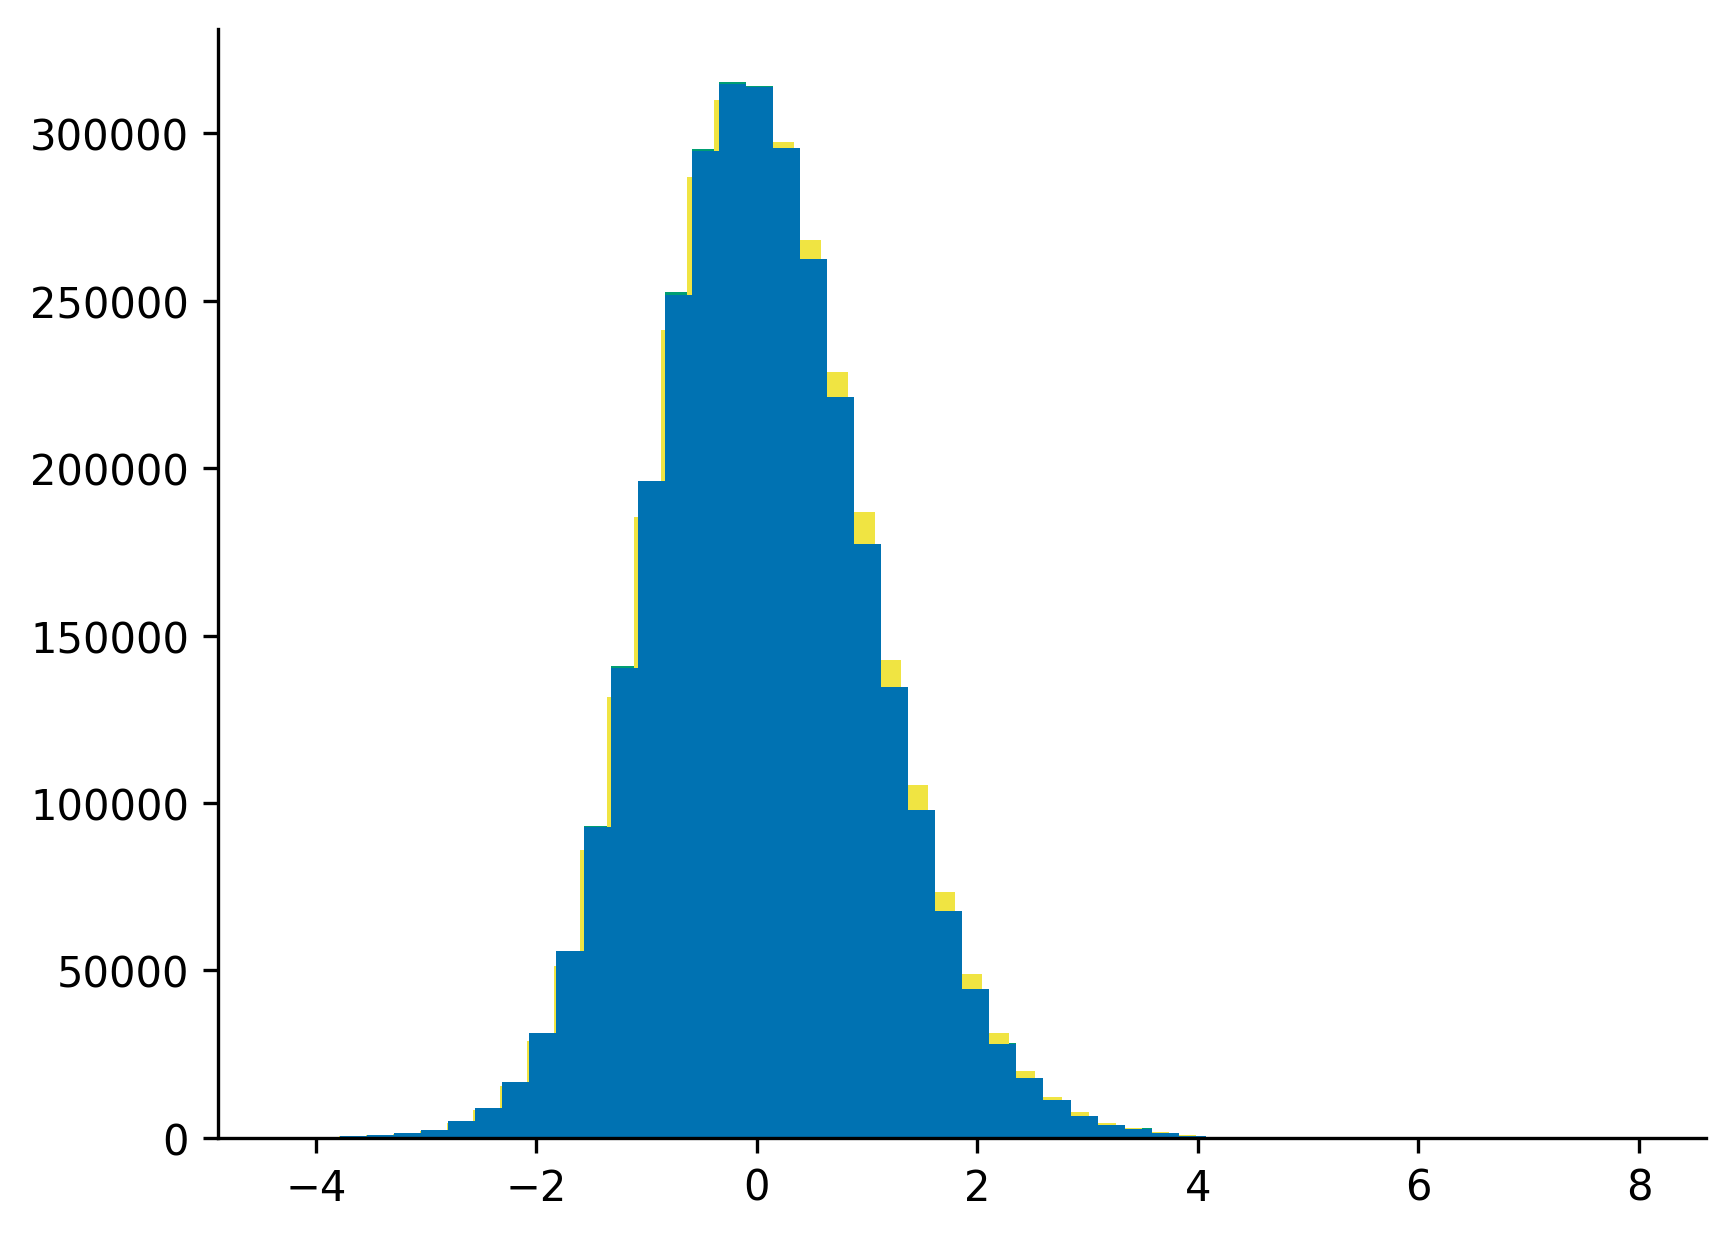

In [15]:
# Predict on the train set
# Loop over the test sets

# Fill the elastic_net_gap column with naN values
df["elastic_net_gap"] = np.nan

coefs = []

n_folds = 5
for test_id, test_fold in enumerate(df["test_fold"].unique()):
    train_dataset = 'ukb_sc' # Train the data on ukb and test on the other datasets.
    test_fold = test_fold
    val_fold = (test_fold + 1) % 5
    train_folds = [fold for fold in range(0, 5) if fold not in [test_fold, val_fold]]
    print(f"Train folds: {train_folds}, Val fold: {val_fold}, Test fold: {test_fold}")
    plt.hist(features_train.flatten(), bins=50)
    train_idxs, val_idxs, test_idxs, ages_train, ages_val, ages_test, ages_train_norm, ages_val_norm, ages_test_norm, features_train, features_val, features_test = get_train_val_test_split(df, train_dataset, train_folds, [val_fold])
    
    final_model = ElasticNet(alpha=best_alpha, l1_ratio=best_l1_ratio, max_iter=1000, tol=1e-5, selection="random")
    final_model.fit(features_train, ages_train_norm)
    coefs.append(final_model.coef_)
        
    preds_train = final_model.predict(features_train)*100
    # Predict on the test set
    ela_preds_test = final_model.predict(features_test)*100

    age_std = 2.0  # Bandwidth for KDE, set to 2 years in age units
    age_grid = np.linspace(ages_train.min(), ages_train.max(), 100)
    def get_kde_mean(value, age, center_age, age_std):
        age_weight = np.exp(-0.5 * ((age - center_age) / age_std) ** 2)
        return np.average(value, weights=age_weight)

    kre_mean_preds = np.array([get_kde_mean(preds_train, ages_train, center_age, age_std) for center_age in age_grid])
    ela_preds_test_unbiased = ela_preds_test - np.interp(ages_test, age_grid, kre_mean_preds) + ages_test
    
    # If a previous value is in elastic_net_gap for the test_idxs, then add the new predictions to the old ones by averaging them
    nan_mask = df.loc[test_idxs, "elastic_net_gap"].isna()
    gap = ela_preds_test_unbiased - ages_test
    df.loc[test_idxs[nan_mask], "elastic_net_gap"] = gap[nan_mask]
    df.loc[test_idxs[~nan_mask], "elastic_net_gap"] = (df.loc[test_idxs[~nan_mask], "elastic_net_gap"]*(test_id) + gap[~nan_mask])/(test_id+1)
    

/tmp/ipykernel_44873/3796097497.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="center", verticalalignment="top")
/tmp/ipykernel_44873/3796097497.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels)


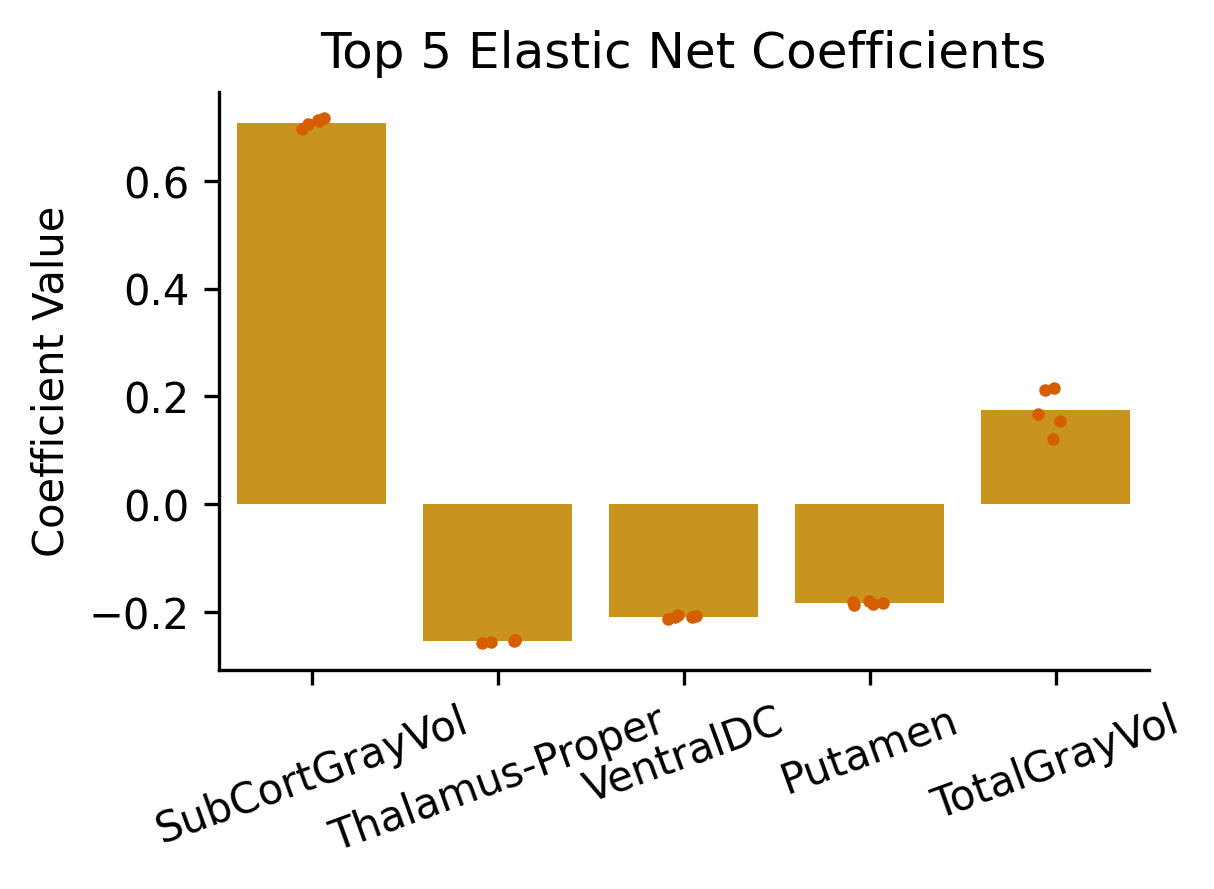

In [16]:
# Get the top 5 coefficients from the elastic net model by taking the mean
# of the coefficients across the 5 folds
coefs = np.array(coefs)

# Normalize for each fold
# This preserves coefficient signs
coefs_normed = coefs / np.sqrt(np.sum(coefs**2, axis=1, keepdims=True))

top_n = 5

mean_coefs = np.mean(coefs_normed, axis=0)
top_n_indices = np.argsort(np.abs(mean_coefs))[-top_n:][::-1]
top_n_features = [features[i] for i in top_n_indices]

# Make long-form dataframe for individual fold coefficients
plot_df = pd.DataFrame({
    "Feature": np.repeat(top_n_features, coefs_normed.shape[0]),
    "Coefficient": np.concatenate([
        coefs_normed[:, feature_idx] for feature_idx in top_n_indices
    ])
})

# Bar values
bar_df = pd.DataFrame({
    "Feature": top_n_features,
    "Mean coefficient": mean_coefs[top_n_indices]
})

fig, ax = plt.subplots(figsize=(4, 2.5), dpi=300)

sns.barplot(
    data=bar_df,
    x="Feature",
    y="Mean coefficient",
    order=top_n_features,
    ax=ax,
    color=colors["Orange"]
)

sns.stripplot(
    data=plot_df,
    x="Feature",
    y="Coefficient",
    order=top_n_features,
    ax=ax,
    color=colors["Vermillion"],
    size=3,
    jitter=True
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="center", verticalalignment="top")
# Remove the "_site_corr_z" from the feature names
new_labels = [label.get_text()[:-len("_site_corr_z")] for label in ax.get_xticklabels()]
ax.set_xticklabels(new_labels)  

ax.set_title(f"Top {top_n} Elastic Net Coefficients")
ax.set_ylabel("Coefficient Value")
ax.set_xlabel("")

plt.show()
# Save the figure
fig.savefig("figures/elastic_net_top_coefficients.svg", bbox_inches="tight")

## XGBoost regression model

In [19]:
def enumerated_product(*args):
    yield from zip(product(*(range(len(x)) for x in args)), product(*args))


if fit_models:
    n_estimators_hyperparams = [100, 300, 600, 1000]
    max_depth_hyperparams = [3, 5, 7]
    learning_rate_hyperparams = [0.01, 0.1, 0.2]

    scores = np.zeros((len(n_estimators_hyperparams), len(max_depth_hyperparams), len(learning_rate_hyperparams)))
    
    best_score = float("inf")
    best_params = {}
    for (i, j, k), (n_estimators, max_depth, learning_rate) in enumerated_product(n_estimators_hyperparams, max_depth_hyperparams, learning_rate_hyperparams):
        model = xgb.XGBRegressor(
            objective="reg:squarederror",
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=learning_rate,
        random_state=42,
        device="cpu",)
        model.fit(features_train, ages_train_norm)
        score = np.mean(np.abs(model.predict(features_val) - ages_val_norm))
        scores[i, j, k] = score
        
        print(f"n_estimators: {n_estimators}, max_depth: {max_depth}, learning_rate: {learning_rate}, validation MAE: {score}")
        if score < best_score:
            best_score = score
            best_params = {
                "n_estimators": n_estimators,
                "max_depth": max_depth,
                "learning_rate": learning_rate
            }
            
    print(f"Best hyperparameters: {best_params}, Best validation MAE: {best_score}")

    # Save the scores and hyperparameters
    with open("/fp/projects01/ec201/userdata/ec-edvardsg/anti_brain_age_data/xgboost_hyperparameters_scores.pkl", "wb") as f:
        pickle.dump({
            "n_estimators_hyperparams": n_estimators_hyperparams,
            "max_depth_hyperparams": max_depth_hyperparams,
            "learning_rate_hyperparams": learning_rate_hyperparams,
            "scores": scores
        }, f)
   
else:
    # Load the scores and hyperparameters
    with open("/fp/projects01/ec201/userdata/ec-edvardsg/anti_brain_age_data/xgboost_hyperparameters_scores.pkl", "rb") as f:
        hyperparams = pickle.load(f)
        n_estimators_hyperparams = hyperparams["n_estimators_hyperparams"]
        max_depth_hyperparams = hyperparams["max_depth_hyperparams"]
        learning_rate_hyperparams = hyperparams["learning_rate_hyperparams"]
        scores = hyperparams["scores"]
        
    best_params_idx = np.unravel_index(np.argmin(scores), scores.shape)
    best_params = {
        "n_estimators": n_estimators_hyperparams[best_params_idx[0]],
        "max_depth": max_depth_hyperparams[best_params_idx[1]],
        "learning_rate": learning_rate_hyperparams[best_params_idx[2]]
    }
    print(f"Best hyperparameters: {best_params}, Best validation MAE: {scores[best_params_idx]}")
    

Best hyperparameters: {'n_estimators': 600, 'max_depth': 5, 'learning_rate': 0.1}, Best validation MAE: 0.04122142872435615


Train folds: [0, 1, 2], Val fold: 4, Test fold: 3
Number of training samples: 25360, Number of validation samples: 8598, Number of test samples: 20585


/tmp/ipykernel_44873/1129752200.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.loc[test_idxs, "xgboost_gap"] = xgb_preds_test_unbiased - ages_test_norm*100


Train folds: [1, 2, 3], Val fold: 0, Test fold: 4
Number of training samples: 25592, Number of validation samples: 8400, Number of test samples: 20551
Train folds: [0, 1, 4], Val fold: 3, Test fold: 2
Number of training samples: 25625, Number of validation samples: 8632, Number of test samples: 20286
Train folds: [0, 3, 4], Val fold: 2, Test fold: 1
Number of training samples: 25630, Number of validation samples: 8333, Number of test samples: 20580
Train folds: [2, 3, 4], Val fold: 1, Test fold: 0
Number of training samples: 25563, Number of validation samples: 8627, Number of test samples: 20353


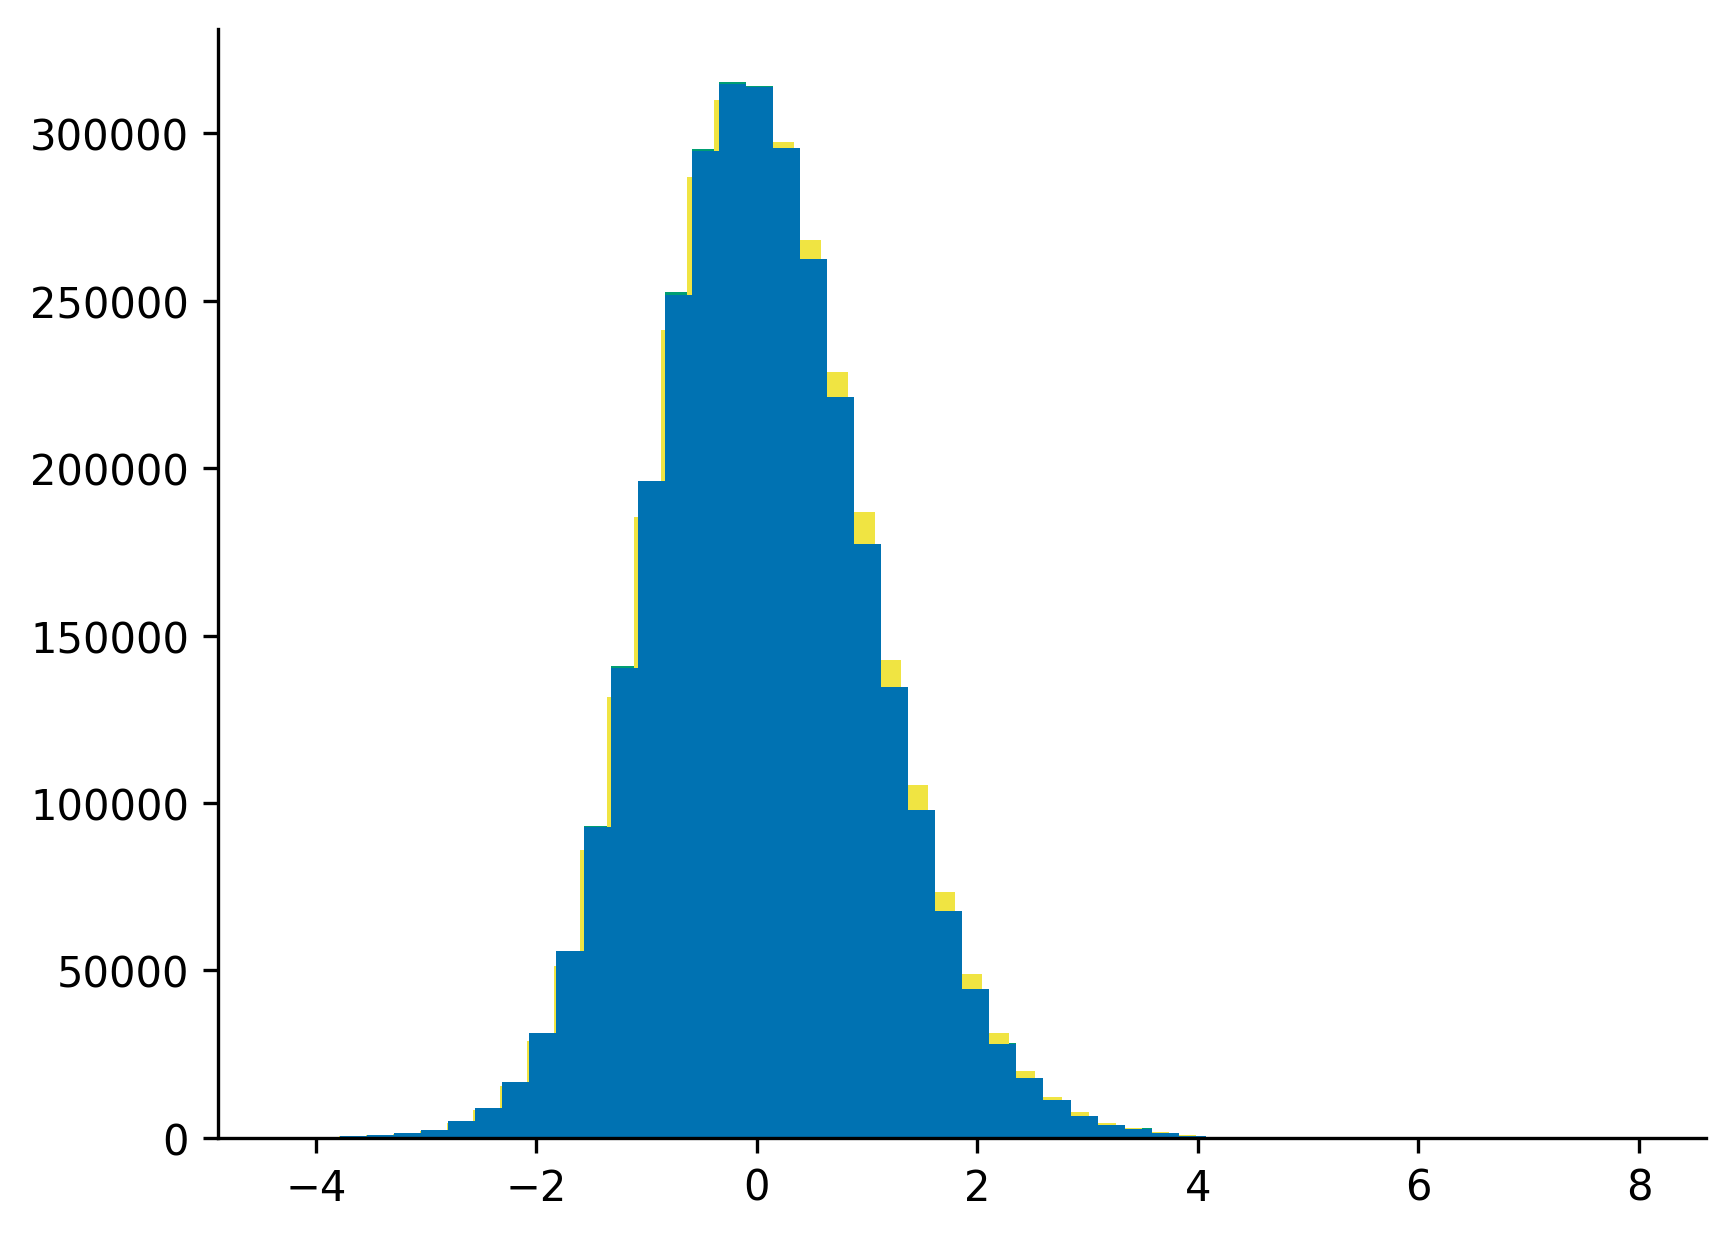

In [20]:
# Predict on the train sets
for test_fold in df["test_fold"].unique():
    train_dataset = 'ukb_sc' # Train the data on ukb and test on the other datasets.
    test_fold = test_fold
    val_fold = (test_fold + 1) % 5
    train_folds = [fold for fold in range(0, 5) if fold not in [test_fold, val_fold]]
    print(f"Train folds: {train_folds}, Val fold: {val_fold}, Test fold: {test_fold}")
    plt.hist(features_train.flatten(), bins=50)
    train_idxs, val_idxs, test_idxs, ages_train, ages_val, ages_test, ages_train_norm, ages_val_norm, ages_test_norm, features_train, features_val, features_test = get_train_val_test_split(df, train_dataset, train_folds, [val_fold])
    
    model = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=best_params["n_estimators"],
        max_depth=best_params["max_depth"],
        learning_rate=best_params["learning_rate"],
        random_state=42,
        device="cpu",)
    model.fit(features_train, ages_train_norm)

    preds_train = model.predict(features_train)*100
    # Predict on the test set
    xgb_preds_test = model.predict(features_test)*100

    age_std = 2.0  # Bandwidth for KDE, set to 2 years in age units
    age_grid = np.linspace(ages_train.min(), ages_train.max(), 100)
    def get_kde_mean(value, age, center_age, age_std):
        age_weight = np.exp(-0.5 * ((age - center_age) / age_std) ** 2)
        return np.average(value, weights=age_weight)

    kre_mean_preds = np.array([get_kde_mean(preds_train, ages_train, center_age, age_std) for center_age in age_grid])
    xgb_preds_test_unbiased = xgb_preds_test - np.interp(ages_test, age_grid, kre_mean_preds) + ages_test
    
    # Add the predictions to the df
    df.loc[test_idxs, "xgboost_gap"] = xgb_preds_test_unbiased - ages_test_norm*100

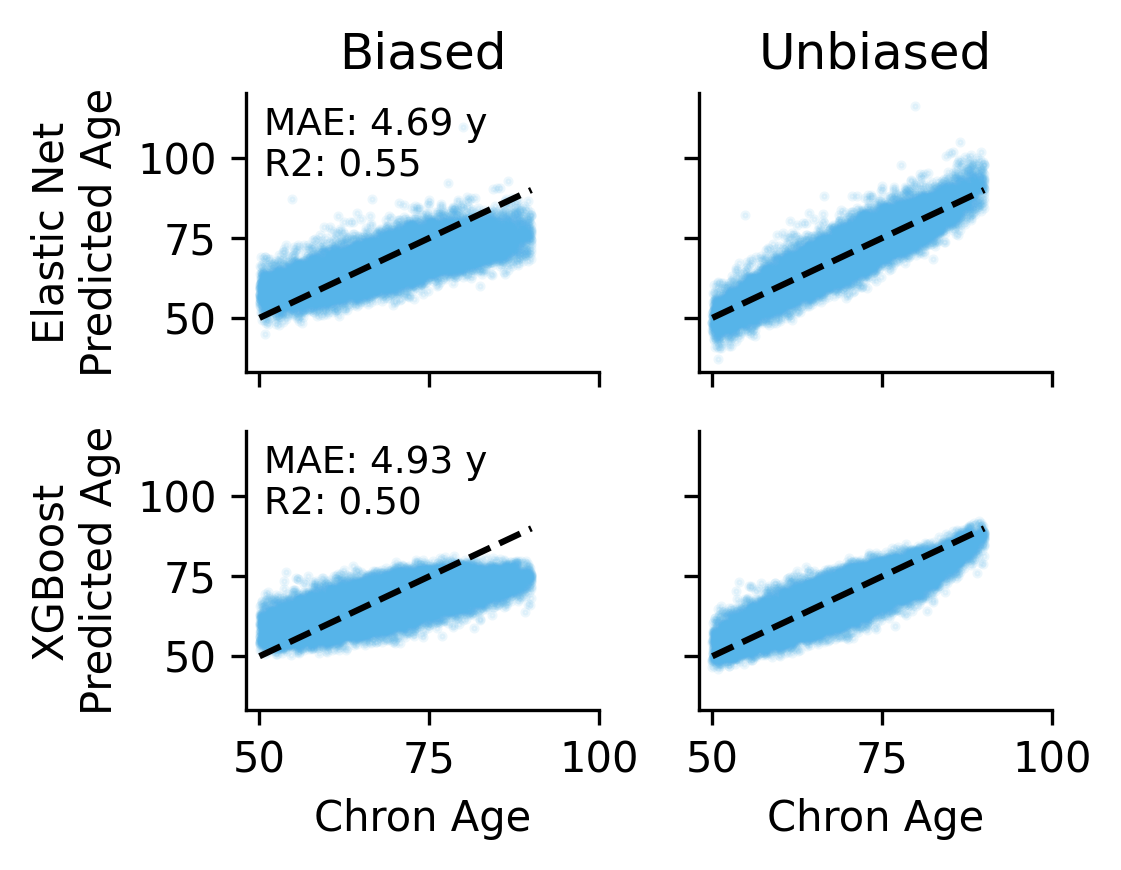

In [22]:
color = colors['Sky Blue']
line_color = "#000000"
x_ticks = [50, 75, 100]


# PLot the predicted vs true ages
fig, axs = plt.subplots(2, 2, figsize=(1.2*3.2, 1.2*2.5), dpi=300, sharex=True, sharey=True)
axs[0, 0].scatter(ages_test, ela_preds_test, alpha=0.1, s=2, color=color, rasterized=True)
axs[0, 0].plot([ages_test.min(), ages_test.max()], [ages_test.min(), ages_test.max()], '--', color=line_color)
axs[0, 0].set_ylabel("Elastic Net\nPredicted Age")
axs[0, 0].set_title("Biased")
# Add the mean absolute error and r2 score to the plot
mae = mean_absolute_error(ages_test, ela_preds_test)
r2 = r2_score(ages_test, ela_preds_test)
axs[0, 0].text(0.05, 0.95, f"MAE: {mae:.2f} y\nR2: {r2:.2f}", transform=axs[0, 0].transAxes, fontsize=9, verticalalignment='top')

axs[0, 1].scatter(ages_test, ela_preds_test_unbiased, alpha=0.1, s=2, color=color, rasterized=True)
axs[0, 1].plot([ages_test.min(), ages_test.max()], [ages_test.min(), ages_test.max()], '--', color=line_color)
axs[0, 1].set_title("Unbiased")

axs[1, 0].scatter(ages_test, xgb_preds_test, alpha=0.1, s=2, color=color, rasterized=True)
axs[1, 0].plot([ages_test.min(), ages_test.max()], [ages_test.min(), ages_test.max()], '--', color=line_color)
axs[1, 0].set_xlabel("Chron Age")
axs[1, 0].set_ylabel("XGBoost\nPredicted Age")

mae = mean_absolute_error(ages_test, xgb_preds_test)
r2 = r2_score(ages_test, xgb_preds_test)
axs[1, 0].text(0.05, 0.95, f"MAE: {mae:.2f} y\nR2: {r2:.2f}", transform=axs[1, 0].transAxes, fontsize=9, verticalalignment='top')

axs[1, 1].scatter(ages_test, xgb_preds_test_unbiased, alpha=0.1, s=2, color=color, rasterized=True)
axs[1, 1].plot([ages_test.min(), ages_test.max()], [ages_test.min(), ages_test.max()], '--', color=line_color)
axs[1, 1].set_xlabel("Chron Age")

axs[1, 1].set_xticks(x_ticks)
axs[1, 1].set_yticks(x_ticks)


# Remove splines from the plots
for i in range(2):
    for j in range(2):
        axs[i, j].spines['top'].set_visible(False)
        axs[i, j].spines['right'].set_visible(False)
    
fig.tight_layout()

# Save as svg
plt.savefig("figures/predicted_vs_true_ages.svg")

## Estimated Tau levels

In [23]:
# Find the middle session for each subject and set the "middle_session" column to True for those sessions
# Compute mean age per subject
mean_age = df.groupby('rid')['age'].mean()

df['mean_age'] = df['rid'].map(mean_age)
df['age_diff'] = (df['age'] - df['mean_age']).abs()
df['middle_session'] = (
    df.groupby('rid')['age_diff']
      .transform(lambda x: x == x.min())
)
# Ensure that there is only one middle session per subject by marking duplicates as False
df = df[df['middle_session']].groupby('rid').first().reset_index()

# Set only the first session as the middle session, and the rest as False
# Check that there is only one middle session per subject
assert df.groupby('rid')['middle_session'].sum().max() == 1, "There are multiple middle sessions per subject in the dataset"

df.drop(columns=['mean_age'], inplace=True)

/tmp/ipykernel_44873/3861105140.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['mean_age'] = df['rid'].map(mean_age)
/tmp/ipykernel_44873/3861105140.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['age_diff'] = (df['age'] - df['mean_age']).abs()
/tmp/ipykernel_44873/3861105140.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragme

In [24]:
# Clip the top and bottom 1% of all slope values
slope_columns = [col for col in df.columns if col.endswith("_slope_z")]
for col in slope_columns:
    lower_bound = df[col].quantile(0.01)
    upper_bound = df[col].quantile(0.99)
    df.loc[df[col] < lower_bound, col] = lower_bound
    df.loc[df[col] > upper_bound, col] = upper_bound

In [25]:
# Plot the distribution of the slope of all the features
n_cols = 10
slope_features = [col for col in df.columns if col.endswith("_slope_z")]
n_rows = int(np.ceil(len(slope_features) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 2 * n_rows), dpi=300)
for i, feature in enumerate(slope_features):
    row = i // n_cols
    col = i % n_cols
    ax = axes[row, col]
    sns.histplot(df[feature], bins=30, ax=ax)
    ax.set_title(feature)
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.tight_layout()

<Axes: >

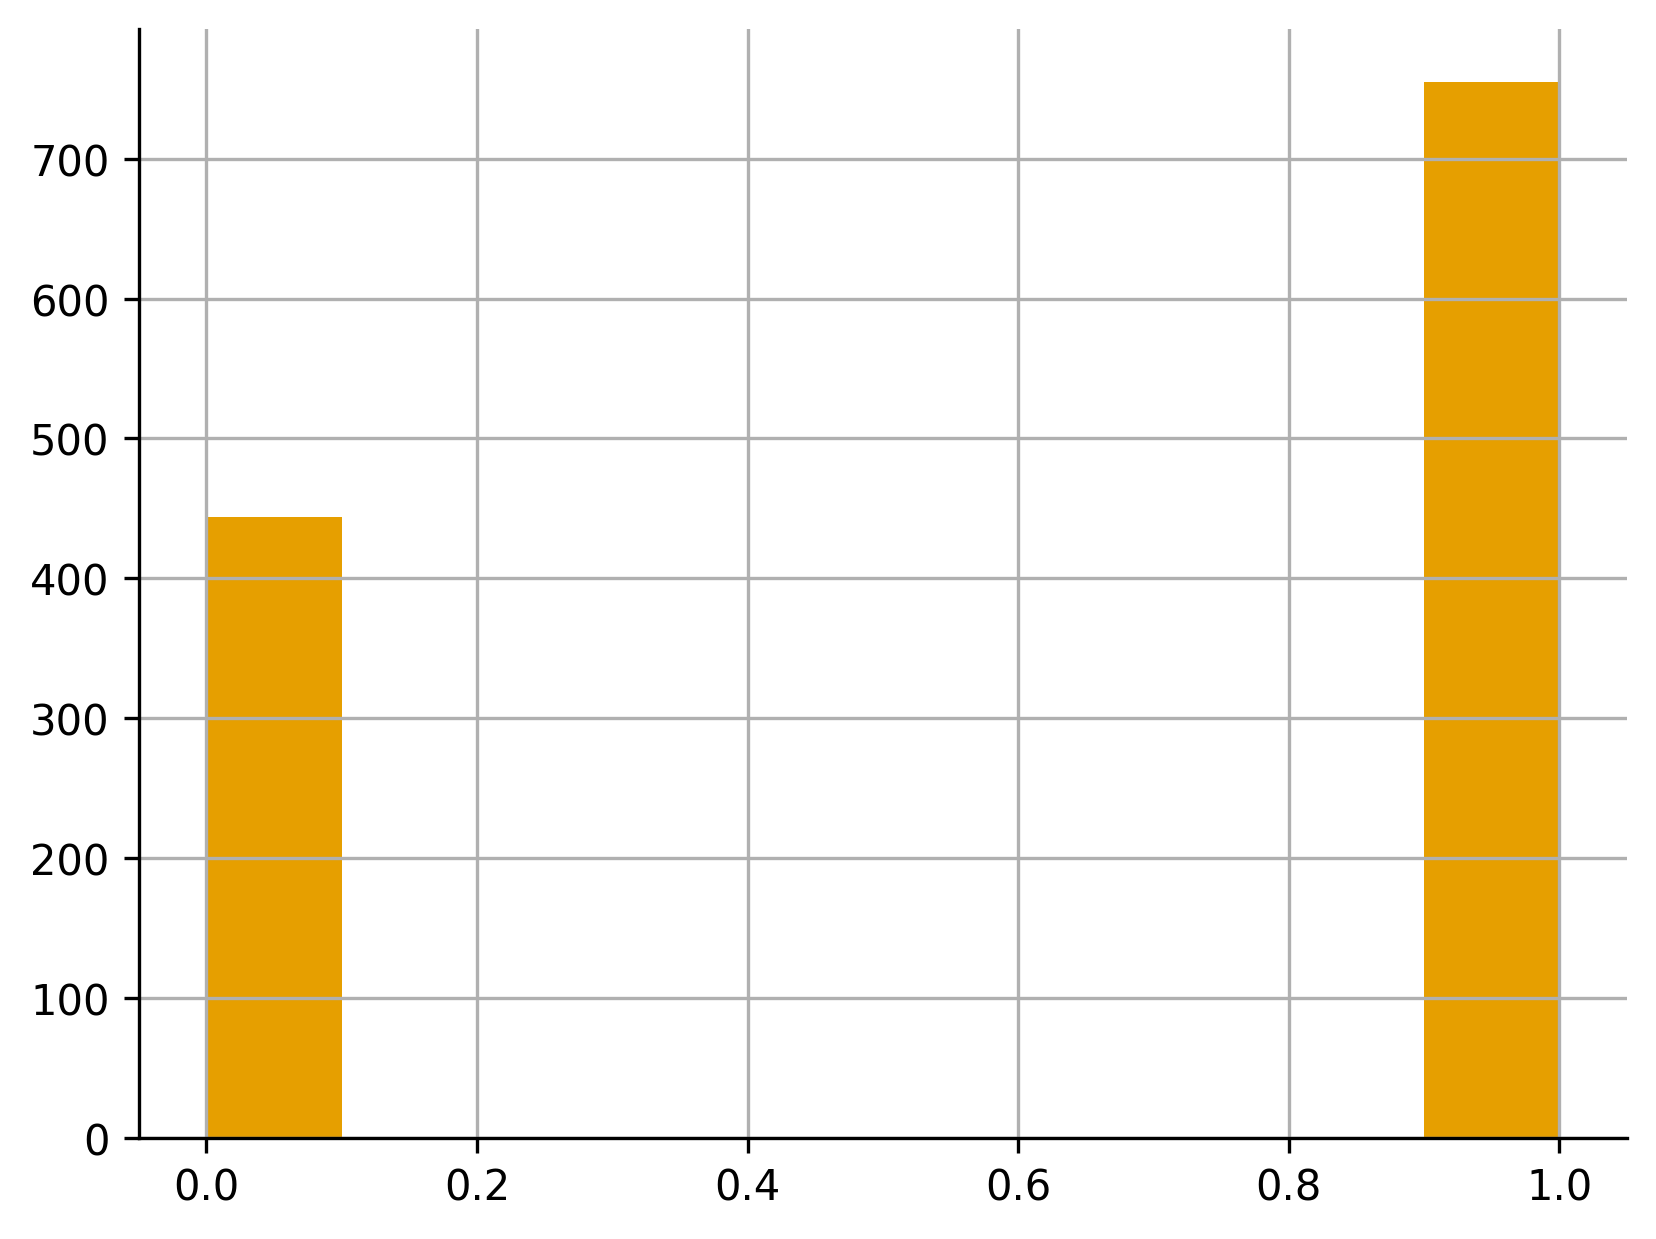

In [27]:
# Set tau positive if estimated tau is > 1.1 while keeping nans as they are
nan_mask = df["esttau"].isna()
df['tau'] = np.nan
df.loc[~nan_mask, "tau"] = (df.loc[~nan_mask, "esttau"] > 1.11).astype(float)

df['tau'].hist()

<Axes: >

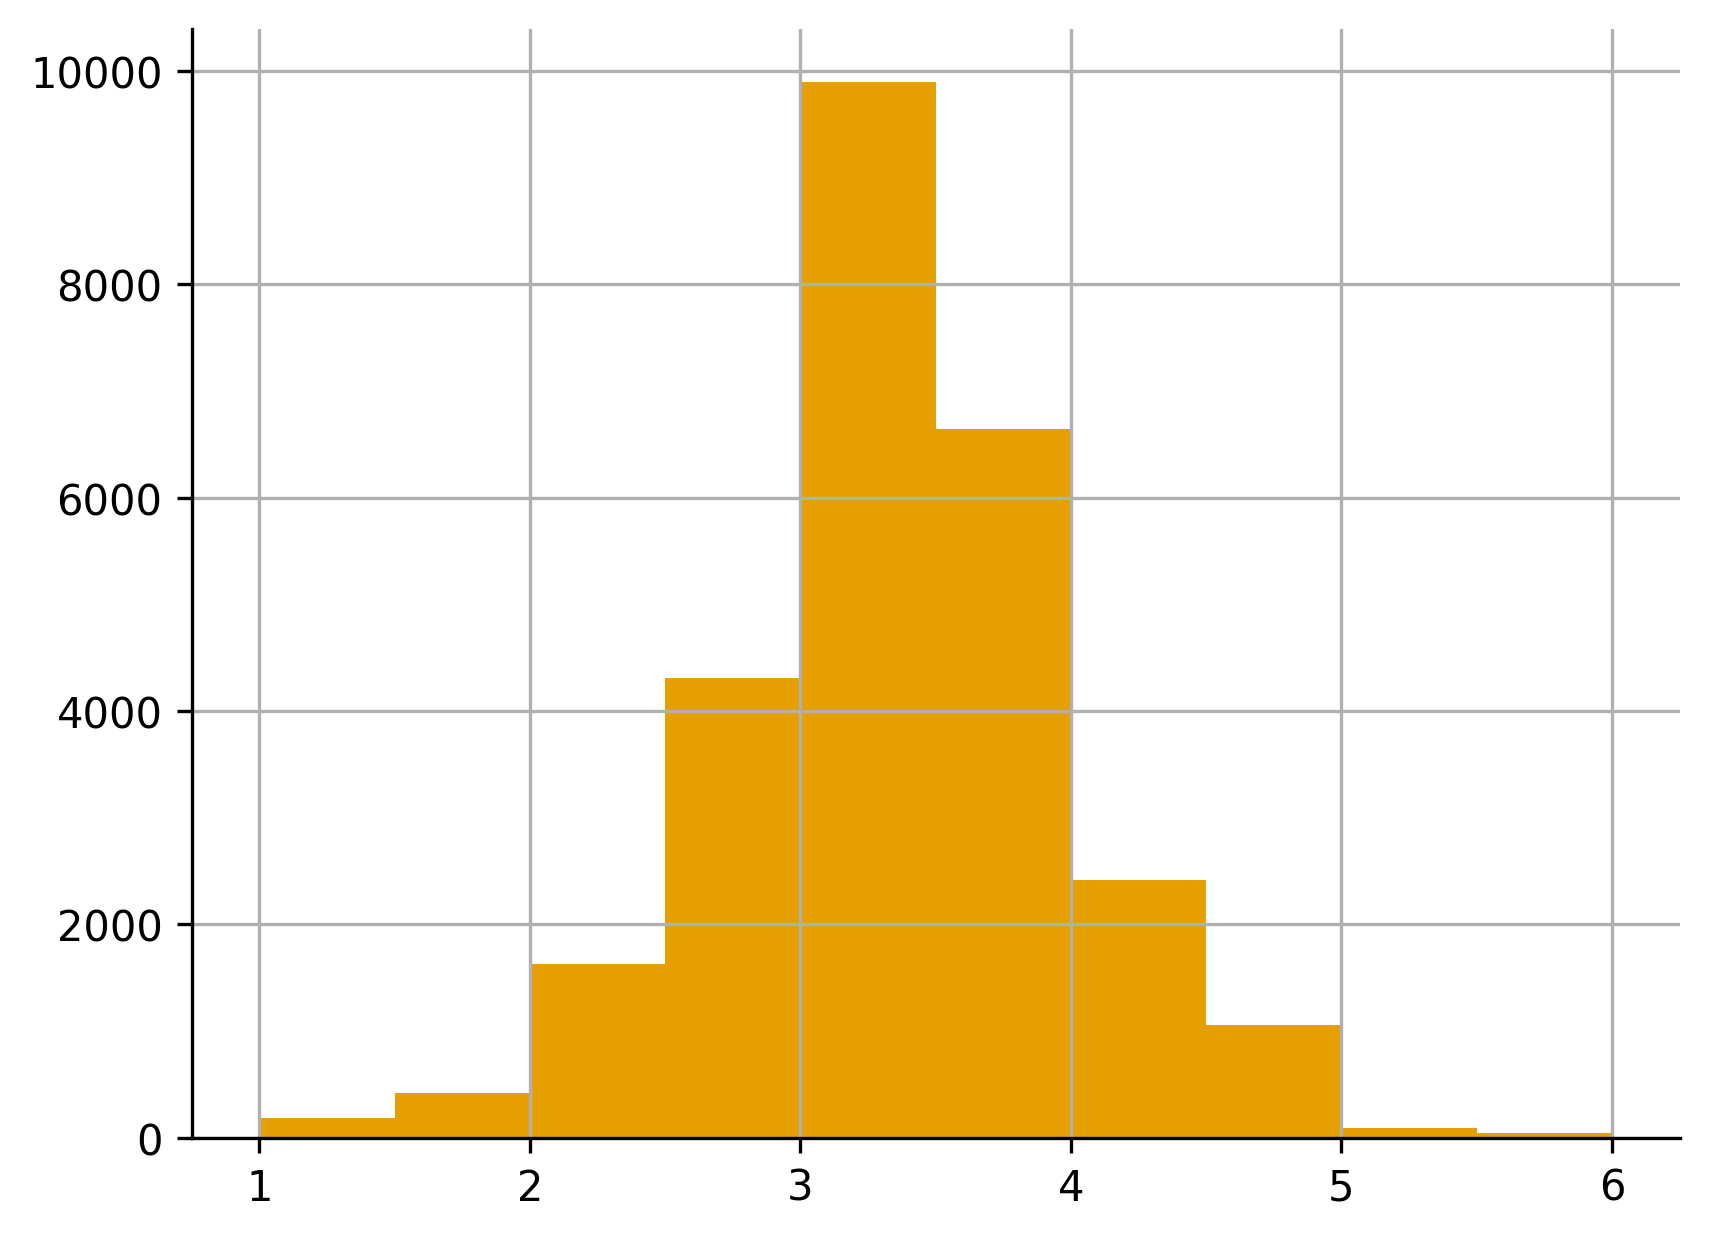

In [28]:
# Divide bw values over 10 by 1000
df.loc[df["bw"] > 10, "bw"] = df.loc[df["bw"] > 10, "bw"] / 1000

# Clip bw values between 1 and 6
df["bw"] = df["bw"].clip(1, 6)

# Plot a histogram of the bw
df["bw"].hist()

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.api as sm
from patsy import bs

# Set tau positive if estimated tau is > 1.1 while keeping nans as they are
nan_mask = df["esttau"].isna()
df['tau'] = np.nan
df.loc[~nan_mask, "tau"] = (df.loc[~nan_mask, "esttau"] > 1.11).astype(float)
# df.loc[~nan_mask, "tau"] = (df.loc[~nan_mask, "esttau"] > 1.2).astype(float)



odds_ratios = []
score_names = ["elastic_net_gap", "xgboost_gap",
               "Hippocampus_site_corr_z", "Hippocampus_slope_z",
               #"TotalGrayVol_site_corr_z", "TotalGrayVol_slope_z",
               #"Amygdala_site_corr_z", "Amygdala_slope_z",
               #"SubCortGrayVol_site_corr_z", "SubCortGrayVol_slope_z",
               "SupraTentorialVol_site_corr_z", "SupraTentorialVol_slope_z"]
for score_name in score_names:
    feature = "tau"

    
    df_subset = df[
        ["age", feature, "EstimatedTotalIntraCranialVol_z", "site", "sex_female", "rid", "age_diff"]
    ].copy()
    df_subset["score"] = df[score_name]

    if "_z" in score_name:
        if not "Ventricle" in score_name:
            df_subset["score"] = -df_subset["score"]

    # Check that there is only one session per subject
    assert df_subset.groupby("rid").size().max() == 1, "There are multiple sessions per subject in the subset"
    
    # Normalize score
    df_subset["score"] = (
        df_subset["score"] - df_subset["score"].mean()
    ) / df_subset["score"].std()
    
    # Also normalize the age
    df_subset["age"] = (df_subset["age"] - df_subset["age"].mean()) / df_subset["age"].std()

    # Drop missing values
    df_subset = df_subset.dropna()

    weights = np.ones(len(df_subset))
    if "slope" in score_name:
        weights = df_subset["age_diff"]**2


    model_formula = (
        f"Q('{feature}') ~ bs(age, df=3) + score + C(site) + C(sex_female)"
    )
    if "_z" in score_name:
       model_formula += " + EstimatedTotalIntraCranialVol_z"
    

    # Weighted logistic regression via GLM Binomial
    model_fit = smf.glm(
        formula=model_formula,
        data=df_subset,
        family=sm.families.Binomial(),
        var_weights=weights
    ).fit()

    odds_ratio = np.exp(model_fit.params["score"])
    conf_int = np.exp(model_fit.conf_int().loc["score"])
    
    odds_ratios.append({
        "model": score_name,
        "odds_ratio": odds_ratio,
        "ci_lower": conf_int.iloc[0],
        "ci_upper": conf_int.iloc[1],
        "n": len(df_subset)
    })

odds_ratios_df = pd.DataFrame(odds_ratios)



In [32]:
# Create a summery table of the df showing the male to female ratio, the mean age, std age, the mean bw, and the mean esttau for each dataset
# Also add the number ofsubject, the number of samples in each dataset, and the number of samples with bw and esttau values in each dataset
# Combine the ukb and ukb_sc datasets into one dataset called ukb, and report the statistics for the combined dataset as well
df["dataset"] = df["dataset"].replace({"ukb_sc": "ukb"})

df_summary = df.copy()

# For the dataset with esttau drop the rows with missing esttau values, and for the dataset with bw drop the rows with missing bw values

esttau_datasets = df_summary[df_summary["esttau"].notna()]["dataset"].unique()
bw_datasets = ['uio']

df_summary = pd.concat([
    df_summary[df_summary["dataset"].isin(esttau_datasets)].dropna(subset=["esttau"]),
    df_summary[df_summary["dataset"].isin(bw_datasets)].dropna(subset=["bw"]),
    df_summary[~df_summary["dataset"].isin(esttau_datasets) & ~df_summary["dataset"].isin(bw_datasets)]
])

summary_table = df_summary.groupby("dataset").agg({
    "sex_female": ["mean"],
    "age": ["mean", "std"],
    "bw": ["mean", "std"],
    "esttau": ["mean", "std"],
    "dataset": "size",
    "bw": lambda x: x.notna().sum(),
    "esttau": lambda x: x.notna().sum(),
    "Hippocampus_slope_z": lambda x: x.notna().sum()
})

summary_table.columns = ["_".join(col) for col in summary_table.columns]
summary_table = summary_table.rename(columns={
    "sex_female_mean": "Male/Female",
    "age_mean": "Age Mean",
    "age_std": "Age Std",
    "bw_mean": "Birth Weight Mean",
    "bw_std": "Birth Weight Std",
    "dataset_size": "N Samples",
    "esttau_mean": "Estimated Tau Mean",
    "esttau_std": "Estimated Tau Std",
    "bw_<lambda>": "N Birth Weight",
    "esttau_<lambda>": "N Estimated Tau",
    "Hippocampus_slope_z_<lambda>": "N Longitudinal"
})


# Format the summary table to have 2 decimal places for the mean and std columns, and no decimal places for the count columns
for col in summary_table.columns:
    if "N " in col:
        summary_table[col] = summary_table[col].apply(lambda x: f"{x:d}")
    else:
        summary_table[col] = summary_table[col].apply(lambda x: f"{x:.2f}")
# Set the order of the columns
summary_table = summary_table[["N Samples", "Male/Female", "Age Mean", "Age Std", "N Birth Weight", "N Estimated Tau", "N Longitudinal"]] 

print(summary_table)

# Add a column for citation and fill it with the appropriate citation for each dataset
summary_table["Citation"] = ""
summary_table.loc["adni", "Citation"] = "\cite{mueller2005alzheimer}"
summary_table.loc["dlbs", "Citation"] = "\cite{denise2025dallas}"
summary_table.loc["habs", "Citation"] = "\cite{dagley2017harvard}"
summary_table.loc["preventad", "Citation"] = "\cite{tremblay2021open}"
summary_table.loc["uio", "Citation"] = "\cite{walhovd2016neurodevelopmental}"
summary_table.loc["ukb", "Citation"] = "\cite{miller2016multimodal}"

# Rename the names of the datasets to be more readable
pretty_dataset_names = {
    "adni": "ADNI",
    "dlbs": "DLBS",
    "habs": "HABS",
    "preventad": "PreventAD",
    "uio": "LCBC",
    "ukb": "UKB"
}
summary_table = summary_table.rename(index=pretty_dataset_names)

# Add a row for the full name of the datasets
name_dict = {
    "ADNI": "Alzheimer's Disease Neuroimaging Initiative",
    "DLBS": "Dallas Lifespan Brain Study",
    "HABS": "Harvard Aging Brain Study",
    "PreventAD": "Pre-symptomatic Evaluation of Experimental or Novel Treatments for AD",
    "LCBC": "Center for Lifespan Changes in Brain and Cognition cohort",
    "UKB": "UK Biobank"
}
summary_table["Name"] = summary_table.index.map(name_dict)

summary_table = summary_table[["Name", "Citation", "N Samples", "N Longitudinal", "Male/Female", "Age Mean", "Age Std", "N Birth Weight", "N Estimated Tau"]]

# Export as latex table
print(summary_table.to_latex())

          N Samples Male/Female Age Mean Age Std N Birth Weight  \
dataset                                                           
adni            762        0.51    72.59    6.83              0   
dlbs            131        0.60    66.48    9.24              0   
habs            195        0.59    75.49    6.14              0   
preventad       111        0.74    64.58    4.87              0   
uio             160        0.68    62.11    7.82            160   
ukb           42319        0.53    65.03    7.47          26535   

          N Estimated Tau N Longitudinal  
dataset                                   
adni                  762            433  
dlbs                  131            125  
habs                  195            187  
preventad             111            111  
uio                     0            108  
ukb                     0           2822  
\begin{tabular}{llllllllll}
\toprule
 & Name & Citation & N Samples & N Longitudinal & Male/Female & Age Mean & Age Std

{'adni': '#e69f00', 'dlbs': '#56b4e9', 'habs': '#009e73', 'preventad': '#f0e442', 'uio': '#0072b2', 'ukb': '#d55e00'}


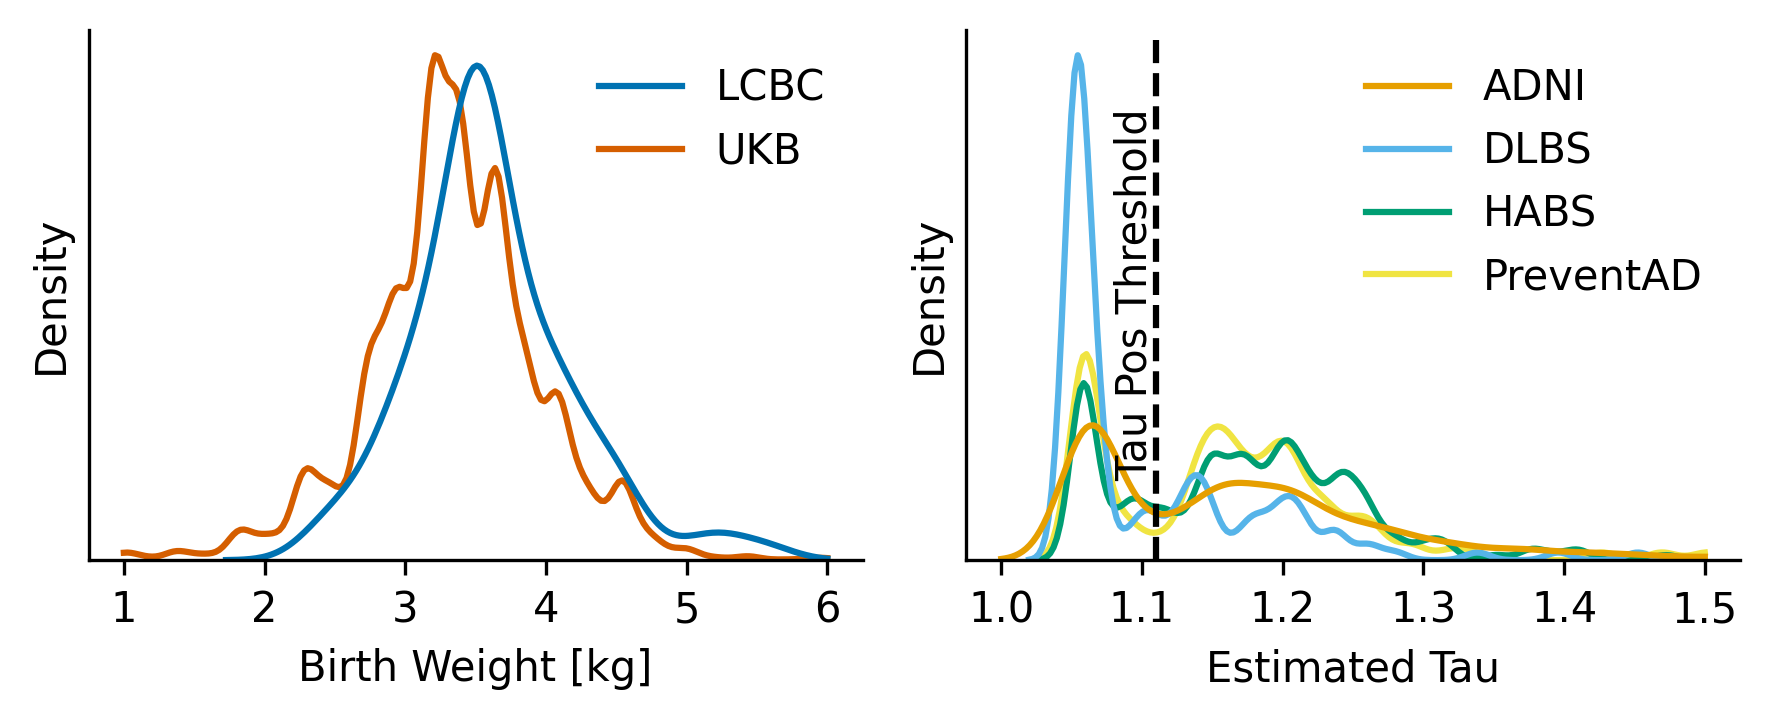

In [33]:
# Plot the distribution of estimated tau for each dataset
fig, axs = plt.subplots(1, 2, figsize=(6, 2.5))
ax = axs[1]

dataset_color_map = {}
unique_df = df['dataset'].unique()
for dataset, color in zip(unique_df, colors.values()):
    dataset_color_map[dataset] = color
    
print(dataset_color_map)
df_tau = df.dropna(subset=["esttau"])
#sns.histplot(data=df_tau, x="esttau", hue="dataset", bins=30, ax=ax, element="step", stat="density", binrange=(1, 1.5))
#sns.kdeplot(data=df_tau, x="esttau", ax=ax, fill=True, clip=(1, 1.5), bw_adjust=0.3, color=colors["Bluish Green"])
sns.kdeplot(data=df_tau, x="esttau", ax=ax,  hue="dataset", common_norm=False, fill=False, clip=(1, 1.5), bw_adjust=0.3, palette=dataset_color_map)

# Plot the vertical line at esttau = 1.11
ax.axvline(1.11, color='black', linestyle='--')
ax.text(1.11, ax.get_ylim()[1]*0.5, 'Tau Pos Threshold', rotation=90, verticalalignment='center', horizontalalignment='right')
ax.set_xlabel("Estimated Tau")
ax.set_ylabel("Density")

leg = ax.get_legend()

leg.set_title("")
leg.set_frame_on(False)

if leg is not None:
    for text in leg.texts:
        old_label = text.get_text()
        text.set_text(pretty_dataset_names.get(old_label, old_label))

ax.set_yticks([])


ax = axs[0]
# Plot the distribution of estimated tau for each dataset
df_bw = df.dropna(subset=["bw"])
# sns.histplot(data=df_bw, x="bw", hue="dataset", bins=30, ax=ax, element="step", stat="density", binrange=(1, 6))
# sns.kdeplot(data=df_bw, x="bw", ax=ax, 
#             fill=True, clip=(1, 6), bw_adjust=1.0, color=colors["Blue"])
sns.kdeplot(data=df_bw, x="bw", ax=ax, hue="dataset", common_norm=False, fill=False, clip=(1, 6), bw_adjust=1.0, legend=True, palette=dataset_color_map)

ax.set_xlabel("Birth Weight [kg]")
ax.set_ylabel("Density")
# Remove the y-axis label and ticks
ax.set_yticks([])
leg = ax.get_legend()

leg.set_title("")
leg.set_frame_on(False)
if leg is not None:
    for text in leg.texts:
        old_label = text.get_text()
        text.set_text(pretty_dataset_names.get(old_label, old_label))
# save the figure
plt.tight_layout()
plt.savefig("figures/estimated_tau_and_birth_weight_distributions.svg")

In [ ]:
# For each of the models and baseline_features compute the correlation between the score/feature and the esttau variable, and plot it as a bar plot with error bars for the standard error of the correlation
partial_corr = []

for score_name in score_names:
    score = df[score_name]        
    feature_subset = ["age", "bw", "EstimatedTotalIntraCranialVol_z", "site", "rid", "age_diff", "sex_female"]
    
    df_subset = df[
        feature_subset
    ].copy()
    
    
    df_subset["score"] = df[score_name]

    
    # Normalize score
    df_subset["score"] = (
        df_subset["score"] - df_subset["score"].mean()
    ) / df_subset["score"].std()

    # Normalize the age
    df_subset["age"] = (df_subset["age"] - df_subset["age"].mean()) / df_subset["age"].std()
    
    # Drop missing values
    df_subset = df_subset.dropna()
    
    # Normalize birthweight
    df_subset["bw"] = (df_subset["bw"] - df_subset["bw"].mean()) / df_subset["bw"].std()
    
    model_formula = (
        f"Q('bw') ~ bs(age, df=3) + score + C(site) + C(sex_female) "
    )
    
    weights = np.ones(len(df_subset))
    if "slope" in score_name:
        weights = df_subset["age_diff"]**2

            
    model_fit = smf.wls(model_formula, df_subset, weights=weights).fit()
    z_value = model_fit.tvalues[f"score"]
    partial_corr.append({
        "model": score_name,
        "effect": model_fit.params[f"score"],
        "se": model_fit.bse[f"score"],
        "ci_lower": model_fit.conf_int().loc[f"score"][0],
        "ci_upper": model_fit.conf_int().loc[f"score"][1],
        "z_value": z_value,
        "n": len(df_subset)
    })
        
partial_corr_df = pd.DataFrame(partial_corr)


/tmp/ipykernel_44873/429163378.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([pretty_labels.get(label, label) for label in plot_df["model"]], fontsize=10)


Tau Positivity Odds Ratios:
            Model Odds Ratio CI Lower CI Upper    N
  Elastic Net BAG       1.21     1.06     1.38 1199
      XGBoost BAG       1.23     1.06     1.42 1199
  Hippocampus Vol       1.47     1.28     1.70 1199
Hippocampus Slope       2.41     1.65     3.52  856
  Total Brain Vol       1.54     1.07     2.20 1199
Total Brain Slope       2.97     1.51     5.85  856
Birth Weight Partial Correlations:
            Model Effect CI Lower CI Upper     N
Total Brain Slope  -0.01    -0.06     0.03  1922
  Total Brain Vol   0.21     0.20     0.23 26695
Hippocampus Slope  -0.02    -0.08     0.04  1922
  Hippocampus Vol   0.13     0.11     0.14 26695
      XGBoost BAG  -0.05    -0.06    -0.04 26695
  Elastic Net BAG  -0.05    -0.06    -0.03 26695


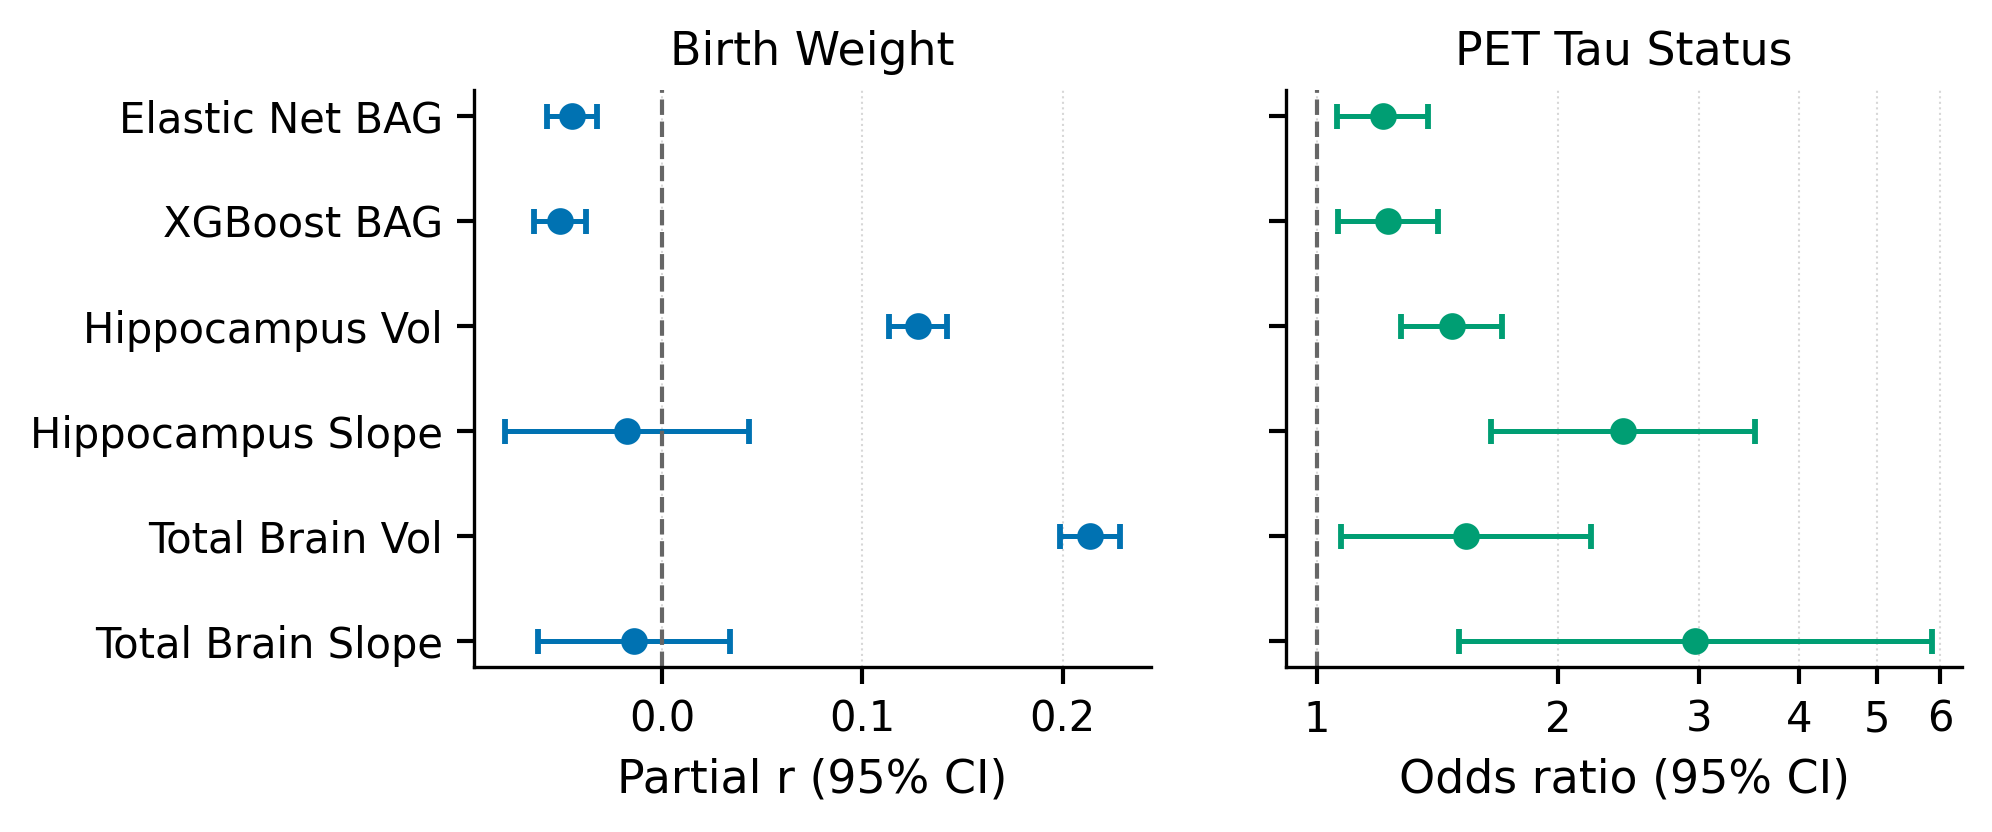

In [35]:

pretty_labels = {
    "elastic_net_gap": "Elastic Net BAG",
    "xgboost_gap": "XGBoost BAG",
    "Hippocampus_site_corr_z": "Hippocampus Vol",
    "Hippocampus_slope_z": "Hippocampus Slope",
    "TotalGrayVol_site_corr_z": "Total Gray Vol",
    "TotalGrayVol_slope_z": "Total Gray Slope",
    "SubCortGrayVol_site_corr_z": "Subcortical Gray Vol",
    "SubCortGrayVol_slope_z": "Subcortical Gray Slope",
    "Amygdala_site_corr_z": "Amygdala Vol",
    "Amygdala_slope_z": "Amygdala Slope",
    "SupraTentorialVol_site_corr_z": "Total Brain Vol",
    "SupraTentorialVol_slope_z": "Total Brain Slope"
}

model_colors = {
    "elastic_net_gap": colors['Orange'],
    "xgboost_gap": colors['Bluish Green'],
    "Hippocampus_site_corr_z": colors['Blue'],
    "Hippocampus_slope_z": colors['Sky Blue'],
    "SupraTentorialVol_site_corr_z": colors['Blue'],
    "SupraTentorialVol_slope_z": colors['Sky Blue']
}





#plot_df = odds_ratios_df_table.sort_values("odds_ratio", ascending=True)
plot_df = odds_ratios_df.set_index("model").loc[score_names[::-1]].reset_index()


fig, axs = plt.subplots(1, 2, figsize=(3.2*2, 2.5), dpi=300, sharey=True)
ax = axs[1]
for _, row in plot_df.iterrows():

    model = row["model"]
    #color = model_colors.get(model, "black")
    color = "#009e73"
    ax.errorbar(
        x=row["odds_ratio"],
        y=model,
        xerr=[[row["odds_ratio"] - row["ci_lower"]],
              [row["ci_upper"] - row["odds_ratio"]]],
        fmt="o",
        color=color,              # marker edge
        ecolor=color,             # CI whiskers
        elinewidth=1.2,
        capsize=3,
        markersize=5,
        markerfacecolor=color,
        markeredgewidth=1.4
    )
    # add the number of samples to the right of the confidence interval
    # ax.text(row["ci_upper"] + 0.05, model, f"n={row['n']}", va="center", fontsize=9)

ax.axvline(1, linestyle="--", linewidth=1, color="0.4")

ax.set_xlabel("Odds ratio (95% CI)", fontsize=11)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_title("PET Tau Status", fontsize=11)

ax.set_yticklabels([pretty_labels.get(label, label) for label in plot_df["model"]], fontsize=10)
ax.tick_params(axis="both", labelsize=10, width=1, length=4)
ax.grid(axis="x", linestyle=":", linewidth=0.5, alpha=0.5)

# Use log scale for x-axis if the range of odds ratios is large
ax.set_xscale("log")
# Set the x-axis limits to show the confidence intervals clearly
xtics = [1, 2, 3, 4, 5, 6]
ax.set_xticks(xtics)
ax.set_xticklabels(xtics)

# Print the odds ratios and confidence intervals in a table use 2 decimal places and pretty labels for the models
odds_ratios_df_table = odds_ratios_df.copy()
odds_ratios_df_table["pretty_model"] = odds_ratios_df_table["model"].map(pretty_labels)
odds_ratios_df_table = odds_ratios_df_table[["pretty_model", "odds_ratio", "ci_lower", "ci_upper", "n"]].rename(columns={"pretty_model": "Model", "odds_ratio": "Odds Ratio", "ci_lower": "CI Lower", "ci_upper": "CI Upper", "n": "N"})
odds_ratios_df_table["Odds Ratio"] = odds_ratios_df_table["Odds Ratio"].map("{:.2f}".format)
odds_ratios_df_table["CI Lower"] = odds_ratios_df_table["CI Lower"].map("{:.2f}".format)
odds_ratios_df_table["CI Upper"] = odds_ratios_df_table["CI Upper"].map("{:.2f}".format)

print("Tau Positivity Odds Ratios:")
print(odds_ratios_df_table.to_string(index=False))

ax = axs[0]

partial_corr_df = partial_corr_df.set_index("model").loc[score_names[::-1]].reset_index()

for idx, row in partial_corr_df.iterrows():

    model = row["model"]
   
    #color = model_colors.get(model, "black")
    color = "#0072b2"
    marker = "o"

    y_pos = score_names[::-1].index(model)
    ax.errorbar(
        x=row["effect"],
        y=y_pos,
        xerr=row["se"] * 2,
        fmt=marker,
        color=color,
        ecolor=color,
        elinewidth=1.2,
        capsize=3,
        markersize=5,
        alpha=1,
        markerfacecolor=color,
        markeredgewidth=1.4
    )

ax.axvline(0, linestyle="--", linewidth=1, color="0.4")

ax.set_xlabel("Partial r (95% CI)", fontsize=11)


ax.set_yticks(range(len(score_names)))
ax.set_yticklabels(
    [pretty_labels.get(label, label) for label in score_names[::-1]],
    fontsize=10
)

ax.set_title(
    "Birth Weight",
    fontsize=11
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(axis="both", labelsize=10, width=1, length=4)

ax.grid(axis="x", linestyle=":", linewidth=0.5, alpha=0.5)


# Print the partial correlations in a table with pretty labels and 2 decimal places
partial_corr_df_table = partial_corr_df.copy()
partial_corr_df_table["pretty_model"] = partial_corr_df_table["model"].map(pretty_labels)
partial_corr_df_table = partial_corr_df_table[["pretty_model", "effect", "ci_lower", "ci_upper", "n"]].rename(columns={"pretty_model": "Model", "effect": "Effect", "ci_lower": "CI Lower", "ci_upper": "CI Upper", "n": "N"})
partial_corr_df_table["Effect"] = partial_corr_df_table["Effect"].map("{:.2f}".format)
partial_corr_df_table["CI Lower"] = partial_corr_df_table["CI Lower"].map("{:.2f}".format)
partial_corr_df_table["CI Upper"] = partial_corr_df_table["CI Upper"].map("{:.2f}".format)
print("Birth Weight Partial Correlations:")
print(partial_corr_df_table.to_string(index=False))

# Save the figure as svg
plt.savefig("figures/empirical_results_summary.svg")

In [36]:
scores_to_comapre = ["Hippocampus_site_corr_z", "Hippocampus_slope_z", "TotalGrayVol_site_corr_z", "TotalGrayVol_slope_z"]
p_values = {}
for score_name in scores_to_comapre:
    df_compare = df[
        ["tau", "age", score_name, "elastic_net_gap",
        "EstimatedTotalIntraCranialVol_z", "site", "sex_female", "age_diff"]].dropna().copy()

    # Flip the score
    if not "Ventricle" in score_name:
        df_compare[score_name] = -df_compare[score_name]
        
    weights = np.ones(len(df_compare))
    if "slope" in score_name:
       weights = df_compare["age_diff"]**2
    
    # Standardize predictors
    for col in ["age", score_name, "elastic_net_gap"]:
        df_compare[col] = (df_compare[col] - df_compare[col].mean()) / df_compare[col].std()

    model = smf.glm(
        formula=f"""
        tau ~ age
            + {score_name}
            + elastic_net_gap
            + C(site)
            + C(sex_female)
            + EstimatedTotalIntraCranialVol_z
        """,
        data=df_compare,
        family=sm.families.Binomial(),
        var_weights=weights
        ).fit()

    hypothesis = f"{score_name} = elastic_net_gap"
    print(f"Comparing {score_name} to Elastic Net BAG:")
    print(model.t_test(hypothesis))
    
    p_values[score_name] = model.t_test(hypothesis).pvalue
    
for score_name, p_value in p_values.items():
    print(f"P-value for {pretty_labels.get(score_name, score_name)} vs Elastic Net BAG: {p_value:.4f}")

Comparing Hippocampus_site_corr_z to Elastic Net BAG:
                             Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0             0.4650      0.159      2.930      0.003       0.154       0.776
Comparing Hippocampus_slope_z to Elastic Net BAG:
                             Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0             0.8434      0.207      4.079      0.000       0.438       1.249
Comparing TotalGrayVol_site_corr_z to Elastic Net BAG:
                             Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------

In [ ]:
# Do a pairwise comaprison using bootstrapping
n_bootstraps = 1000
# Fit the elastic Net model
# Fit the other model
# Compute the difference in the coefficients
# Count the number of times the other model has a higher coefficient than the elastic net model

df_compare = df[
    ["tau", "age", "elastic_net_gap", "EstimatedTotalIntraCranialVol_z", "site", "sex_female", "age_diff"] + scores_to_comapre
].dropna().copy()

bootstrap_results = {score_name: 0 for score_name in scores_to_comapre}
for i in range(n_bootstraps):
    if i % 100 == 0:
        print(f"Bootstrap iteration {i}/{n_bootstraps}")
    df_bootstrap = df_compare.sample(frac=1, replace=True)
    weights = np.ones(len(df_bootstrap))
    model_elastic_net = smf.glm(
        formula=f"""
        tau ~ bs(age, df=3)
            + elastic_net_gap
            + C(site)
            + C(sex_female)
            + EstimatedTotalIntraCranialVol_z
        """,
        data=df_bootstrap,
        family=sm.families.Binomial(),
        var_weights=weights
        ).fit()
    
    for score_name in scores_to_comapre:
        model_other = smf.glm(
            formula=f"""
            tau ~ bs(age, df=3)
                + {score_name}
                + C(site)
                + C(sex_female)
                + EstimatedTotalIntraCranialVol_z
            """,
            data=df_bootstrap,
            family=sm.families.Binomial(),
            var_weights=weights
            ).fit()
        
        if model_other.params[score_name] > model_elastic_net.params["elastic_net_gap"]:
            bootstrap_results[score_name] += 1

Bootstrap iteration 0/1000
Bootstrap iteration 100/1000
Bootstrap iteration 200/1000
Bootstrap iteration 300/1000
Bootstrap iteration 400/1000
Bootstrap iteration 500/1000
Bootstrap iteration 600/1000
Bootstrap iteration 700/1000
Bootstrap iteration 800/1000
Bootstrap iteration 900/1000


In [38]:
# Compute the p-values
for score_name, count in bootstrap_results.items():
    p_value = count / n_bootstraps
    print(f"Bootstrap p-value for {pretty_labels.get(score_name, score_name)} vs Elastic Net BAG: {p_value:.4f}")

Bootstrap p-value for Hippocampus Vol vs Elastic Net BAG: 0.0010
Bootstrap p-value for Hippocampus Slope vs Elastic Net BAG: 0.0000
Bootstrap p-value for Total Gray Vol vs Elastic Net BAG: 0.5700
Bootstrap p-value for Total Gray Slope vs Elastic Net BAG: 0.0500
